In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('titanic')

100%|██████████| 34.1k/34.1k [00:00<00:00, 29.7MB/s]

Extracting files...


Kaggle credentials set.
Kaggle credentials successfully validated.


In [18]:
path = kagglehub.competition_download('titanic')
print(path)
import os

os.listdir(path)

df = pd.read_csv(os.path.join(path, "train.csv"))

df.head()

df.info()

/root/.cache/kagglehub/competitions/titanic
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
df.shape

df.describe()

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [27]:
# Cleaning the data

# Fill missing Age values
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Drop Cabin if it exists
df.drop(columns=["Cabin"], inplace=True, errors="ignore")

# Fill missing Embarked values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [30]:
# Converting raw ages into categories
bins = [0,12,18,30,50,80]

labels = ["Child",
          "Teen",
          "Young Adult",
          "Adult",
          "Senior"]

df["AgeGroup"] = pd.cut(df["Age"],
                        bins=bins,
                        labels=labels)
df[["Age","AgeGroup"]].head()

df["FamilySize"] = df["SibSp"] + df["Parch"]

# **Analysis Questions** <br>
## 1) Survival Rate by Age Group
## 2) Survival Rate by Embarkation Port
## 3) Survival Rate by Family Size





/tmp/ipykernel_1787/1627305066.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.331096
Adult          0.423237
Senior         0.343750
Name: Survived, dtype: float64


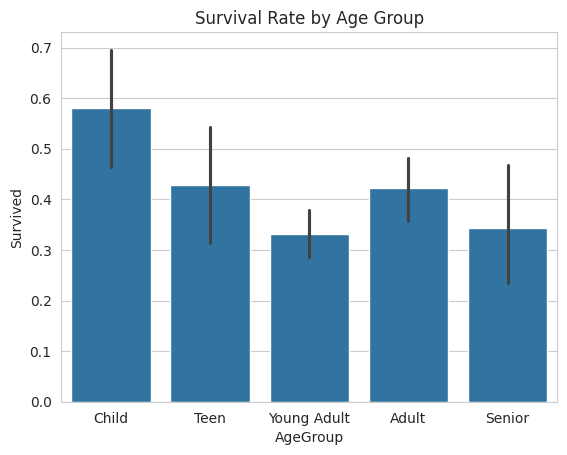

In [32]:
# 1) Survival Rate by Age Group
age_survival = df.groupby("AgeGroup")["Survived"].mean()

print(age_survival)

sns.barplot(x="AgeGroup",
            y="Survived",
            data=df)

plt.title("Survival Rate by Age Group")

plt.show()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


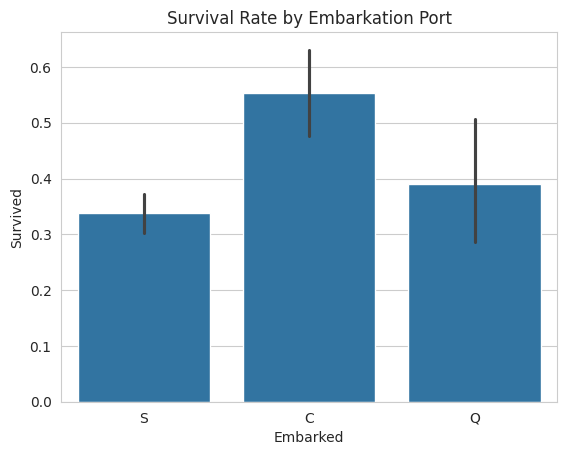

In [33]:
# 2) Survival Rate by Embarkation Port
embark = df.groupby("Embarked")["Survived"].mean()

print(embark)

sns.barplot(x="Embarked",
            y="Survived",
            data=df)

plt.title("Survival Rate by Embarkation Port")

plt.show()

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


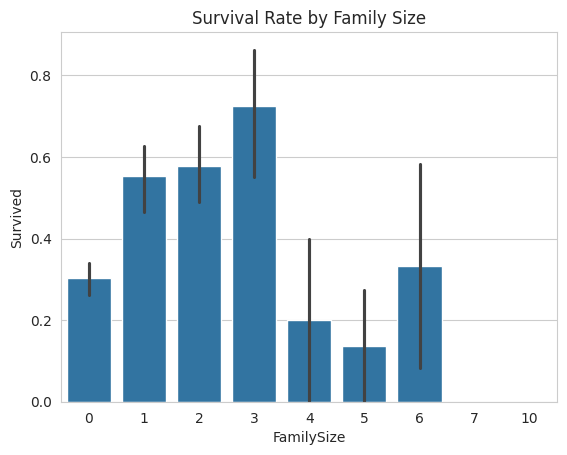

In [35]:
# 3) Survival Rate by Family Size
family = df.groupby("FamilySize")["Survived"].mean()

print(family)

sns.barplot(x="FamilySize",
            y="Survived",
            data=df)

plt.title("Survival Rate by Family Size")

plt.show()

# **Visualizations** <br>
## 1) Age distribution histogram
## 2) Heatmap of correlations
## 3) Survival by family size (bar plot)

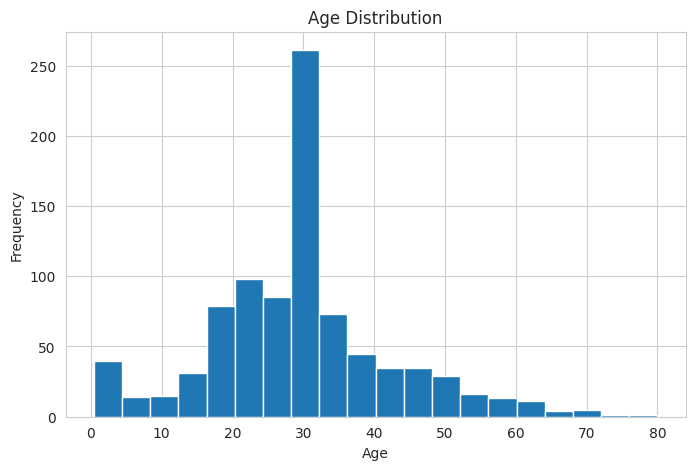

In [36]:
# 1) Age distribution histogram
plt.figure(figsize=(8,5))

plt.hist(df["Age"],
         bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

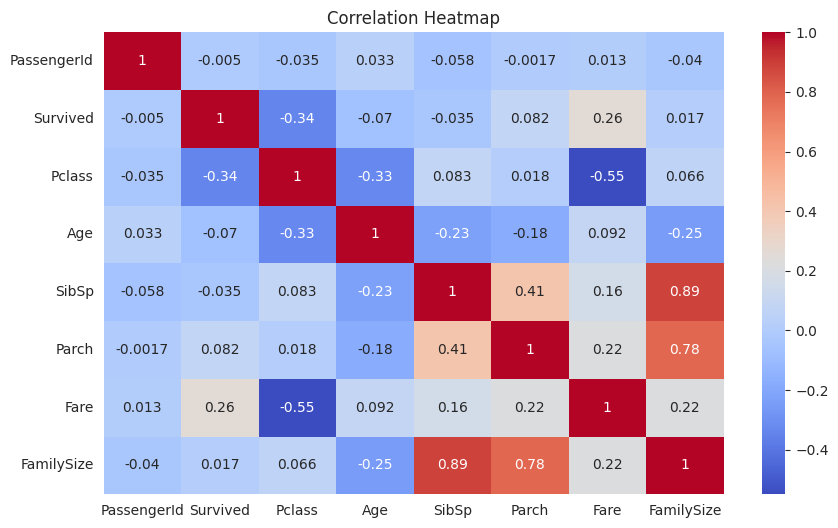

In [37]:
# 2) Heatmap of correlations
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## Passenger Class negatively correlates with survival.
## Fare positively correlates with survival.
## Family variables correlate with Family Size.

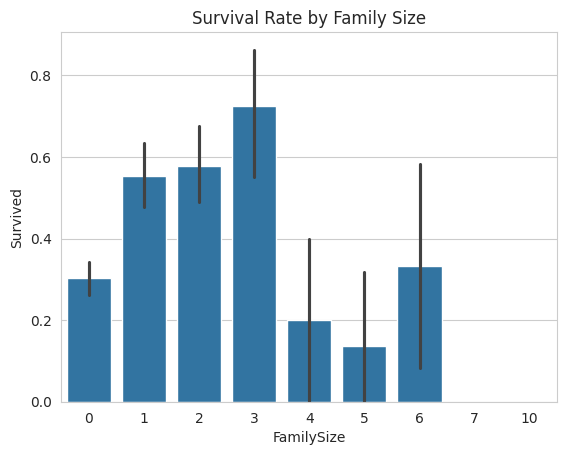

In [39]:
# 3) Survival by family size (bar plot)
sns.barplot(x="FamilySize",
            y="Survived",
            data=df)

plt.title("Survival Rate by Family Size")

plt.show()

# Often passengers with very small families perform better than huge families

## **CONCLUSION**

### Age Group:
#### Children had a higher survival rate than adults, indicating evacuation policies prioritized younger passengers.

### Embarkation:
#### Passengers embarking from Port C had the highest survival rate, possibly because more first-class passengers boarded there.

### Family Size:
#### Passengers traveling with small families showed better survival than those traveling alone or in very large groups.

### Overall
#### Passenger class, fare, age, and family size all influenced survival.